In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ratings = pd.read_csv("ratings.csv").head(20000)
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

In [4]:
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [5]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
ratings = pd.read_csv("ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
movies = pd.read_csv("movies.csv")
movies.tail

<bound method NDFrame.tail of       movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father of the Bride Part II (1995)   
...       ...                                        ...   
9737   193581  Black Butler: Book of the Atlantic (2017)   
9738   193583               No Game No Life: Zero (2017)   
9739   193585                               Flint (2017)   
9740   193587        Bungo Stray Dogs: Dead Apple (2018)   
9741   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  
0     Adventure|Animation|Children|Comedy|Fantasy  
1                      Adventure|Children|Fantasy  
2                                  Comedy|Romance  
3                            Comedy|Drama

In [8]:
data = pd.merge(ratings, movies, on='movieId')

In [9]:
data.shape

(100836, 6)

In [10]:
data.head

<bound method NDFrame.head of         userId  movieId  rating   timestamp                           title  \
0            1        1     4.0   964982703                Toy Story (1995)   
1            1        3     4.0   964981247         Grumpier Old Men (1995)   
2            1        6     4.0   964982224                     Heat (1995)   
3            1       47     5.0   964983815     Seven (a.k.a. Se7en) (1995)   
4            1       50     5.0   964982931      Usual Suspects, The (1995)   
...        ...      ...     ...         ...                             ...   
100831     610   166534     4.0  1493848402                    Split (2017)   
100832     610   168248     5.0  1493850091   John Wick: Chapter Two (2017)   
100833     610   168250     5.0  1494273047                  Get Out (2017)   
100834     610   168252     5.0  1493846352                    Logan (2017)   
100835     610   170875     3.0  1493846415  The Fate of the Furious (2017)   

                     

In [11]:
data.sample(5)

,userId,movieId,rating,timestamp,title,genres
34439,232,37741,3.5,1247190421,Capote (2005),Crime|Drama
22649,155,1302,3.0,961860789,Field of Dreams (1989),Children|Drama|Fantasy
87152,562,2000,5.0,1368896421,Lethal Weapon (1987),Action|Comedy|Crime|Drama
89308,579,3176,5.0,958882104,"Talented Mr. Ripley, The (1999)",Drama|Mystery|Thriller
78073,484,3177,4.0,1342300169,Next Friday (2000),Comedy


In [12]:
data.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')

In [13]:
user_item_matrix = data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
).fillna(0)


user_item_matrix = user_item_matrix.iloc[:, :500]

In [14]:
user_item_matrix.shape

(610, 500)

In [15]:
data = pd.merge(ratings, movies, on='movieId')

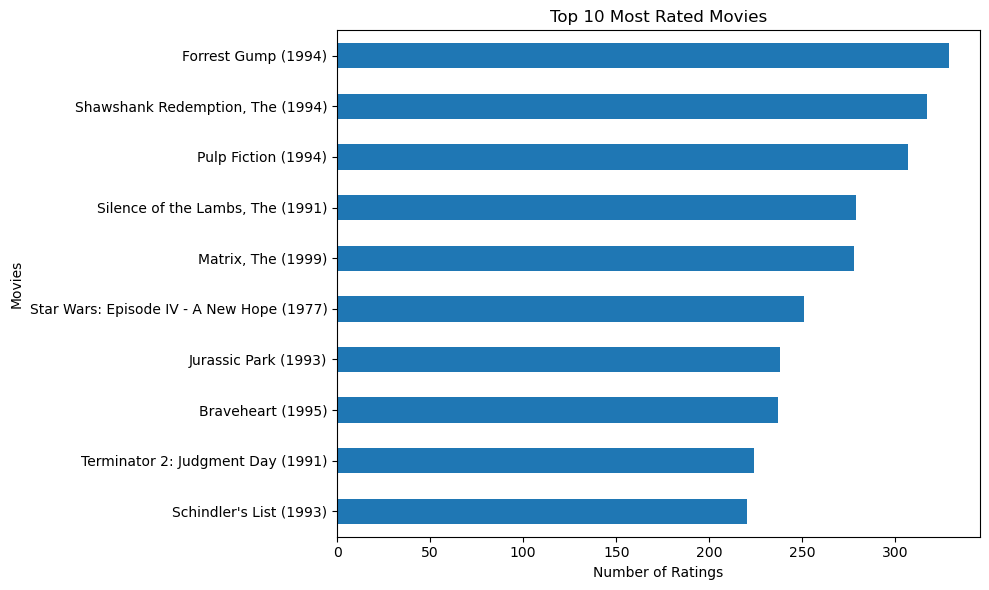

In [16]:
movie_counts = data.groupby('title')['rating'].count().sort_values(ascending=False)

top_movies = movie_counts.head(10)

plt.figure(figsize=(10,6))
top_movies.sort_values().plot(kind='barh')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movies")

plt.tight_layout()
plt.show()

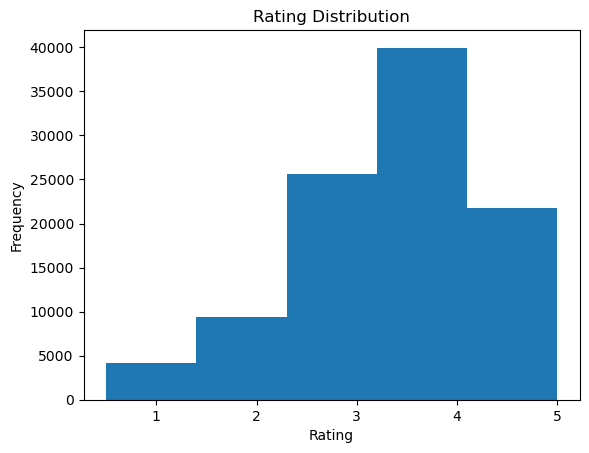

In [17]:
data['rating'].plot(kind='hist', bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [18]:
user_item_matrix = data.pivot_table(
    index="userId", columns="title", values="rating")

user_item_matrix.shape

(610, 9719)

In [19]:
total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1]

missing_values = user_item_matrix.isna().sum().sum()

sparsity = (missing_values / total_cells) * 100

round(sparsity, 2)

98.3

In [20]:
user_item_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
user_item_matrix.iloc[:5, :5]

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997)
userId,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


In [22]:
popular_movies = data.groupby('title')['rating'].count().sort_values(ascending=False)

top_movies = popular_movies.head(5).index

user_item_matrix.loc[:, top_movies].head()

title,Forrest Gump (1994),"Shawshank Redemption, The (1994)",Pulp Fiction (1994),"Silence of the Lambs, The (1991)","Matrix, The (1999)"
userId,,,,,
1,4.0,NaN,3.0,4.0,5.0
2,NaN,3.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,1.0,5.0,1.0
5,NaN,3.0,5.0,NaN,NaN


In [23]:
user_item_matrix.loc[1].dropna()

title
13th Warrior, The (1999)                4.0
20 Dates (1998)                         4.0
Abyss, The (1989)                       4.0
Adventures of Robin Hood, The (1938)    5.0
Alice in Wonderland (1951)              5.0
                                       ... 
Wolf Man, The (1941)                    5.0
X-Men (2000)                            5.0
Young Frankenstein (1974)               5.0
Young Sherlock Holmes (1985)            3.0
¡Three Amigos! (1986)                   4.0
Name: 1, Length: 232, dtype: float64

In [24]:
user_item_filled = user_item_matrix.fillna(0)

In [25]:
user_item_filled.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_filled)

user_similarity[:5, :5]

array([[1.        , 0.02728287, 0.05972026, 0.19439477, 0.12907989],
       [0.02728287, 1.        , 0.        , 0.00372587, 0.01661444],
       [0.05972026, 0.        , 1.        , 0.00225139, 0.00501972],
       [0.19439477, 0.00372587, 0.00225139, 1.        , 0.1286589 ],
       [0.12907989, 0.01661444, 0.00501972, 0.1286589 , 1.        ]])

In [27]:
import pandas as pd

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

user_similarity_df.iloc[:5, :5]

userId,1,2,3,4,5
userId,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080
2,0.027283,1.000000,0.000000,0.003726,0.016614
3,0.059720,0.000000,1.000000,0.002251,0.005020
4,0.194395,0.003726,0.002251,1.000000,0.128659
5,0.129080,0.016614,0.005020,0.128659,1.000000


In [28]:
similar_users = user_similarity_df[1].sort_values(ascending=False)

similar_users.head(5)

userId
1      1.000000
266    0.357408
313    0.351562
368    0.345127
57     0.345034
Name: 1, dtype: float64

In [29]:
user_watched = user_item_matrix.loc[1]

watched_movies = user_watched[user_watched.notna()]

watched_movies.head()

title
13th Warrior, The (1999)                4.0
20 Dates (1998)                         4.0
Abyss, The (1989)                       4.0
Adventures of Robin Hood, The (1938)    5.0
Alice in Wonderland (1951)              5.0
Name: 1, dtype: float64

In [30]:
recommendations = []

for user in similar_users.index[1:6]:
    movies = user_item_matrix.loc[user]
    movies = movies[movies >= 4]
    
    for movie in movies.index:
        if movie not in watched_movies.index:
            recommendations.append(movie)

recommendations = list(set(recommendations))[:5]

recommendations

['Escape from the Planet of the Apes (1971)',
 'Bowfinger (1999)',
 'Toy Story 2 (1999)',
 'Outbreak (1995)',
 'Sting, The (1973)']

In [31]:
user_item_filled = user_item_matrix.fillna(0)

In [32]:
movie_user_matrix = user_item_filled.T
movie_user_matrix.shape

(9719, 610)

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(movie_user_matrix)

movie_similarity[:5, :5]

array([[1.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.70710678, 0.        , 0.        ],
       [0.        , 0.70710678, 1.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 1.        , 0.85749293],
       [0.        , 0.        , 0.        , 0.85749293, 1.        ]])

In [52]:
import pandas as pd

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

movie_similarity_df.iloc[:5, :5]

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997)
title,,,,,
'71 (2014),1.0,0.000000,0.000000,0.000000,0.000000
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.000000,0.000000
'Round Midnight (1986),0.0,0.707107,1.000000,0.000000,0.000000
'Salem's Lot (2004),0.0,0.000000,0.000000,1.000000,0.857493
'Til There Was You (1997),0.0,0.000000,0.000000,0.857493,1.000000


In [53]:
movie_similarity_df['Mission: Impossible (1996)'].sort_values(ascending=False).head(10)

title
Mission: Impossible (1996)                           1.000000
Independence Day (a.k.a. ID4) (1996)                 0.677354
Jurassic Park (1993)                                 0.592277
Twister (1996)                                       0.588407
Rock, The (1996)                                     0.565168
GoldenEye (1995)                                     0.550653
Terminator 2: Judgment Day (1991)                    0.545612
Speed (1994)                                         0.545093
Star Wars: Episode VI - Return of the Jedi (1983)    0.544795
Toy Story (1995)                                     0.538913
Name: Mission: Impossible (1996), dtype: float64

In [54]:
def recommend_similar_movies(movie_name):
    similar_movies = movie_similarity_df[movie_name].sort_values(ascending=False)
    
  
    similar_movies = similar_movies.iloc[1:6]
    
    return similar_movies

recommend_similar_movies('Toy Story (1995)')

title
Toy Story 2 (1999)                           0.572601
Jurassic Park (1993)                         0.565637
Independence Day (a.k.a. ID4) (1996)         0.564262
Star Wars: Episode IV - A New Hope (1977)    0.557388
Forrest Gump (1994)                          0.547096
Name: Toy Story (1995), dtype: float64

In [55]:
!pip install cython


In [56]:
!pip install numpy


In [57]:

!pip install wheel

In [58]:
!pip install ipykernel

In [59]:
import sys
print(sys.version)
print(sys.executable)

3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
C:\Users\BOMBAY HIGH COURT\anaconda3\envs\final_env\python.exe


In [60]:
!"C:\Users\BOMBAY HIGH COURT\anaconda3\envs\surprise_env\python.exe" -m pip install ipykernel

In [61]:
!"C:\Users\BOMBAY HIGH COURT\anaconda3\envs\surprise_env\python.exe" -m ipykernel install --user --name=surprise_env --display-name "Python (surprise_env)"

Installed kernelspec surprise_env in C:\Users\BOMBAY HIGH COURT\AppData\Roaming\jupyter\kernels\surprise_env


In [62]:
import sys
print(sys.version)
print(sys.executable)

3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
C:\Users\BOMBAY HIGH COURT\anaconda3\envs\final_env\python.exe


In [63]:
import sys
print(sys.version)

3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]


In [64]:
from surprise import Dataset, Reader

In [65]:
import pandas as pd
import numpy as np
print("working")

working


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [72]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

print("Data loaded successfully")
data.head()

Data loaded successfully


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


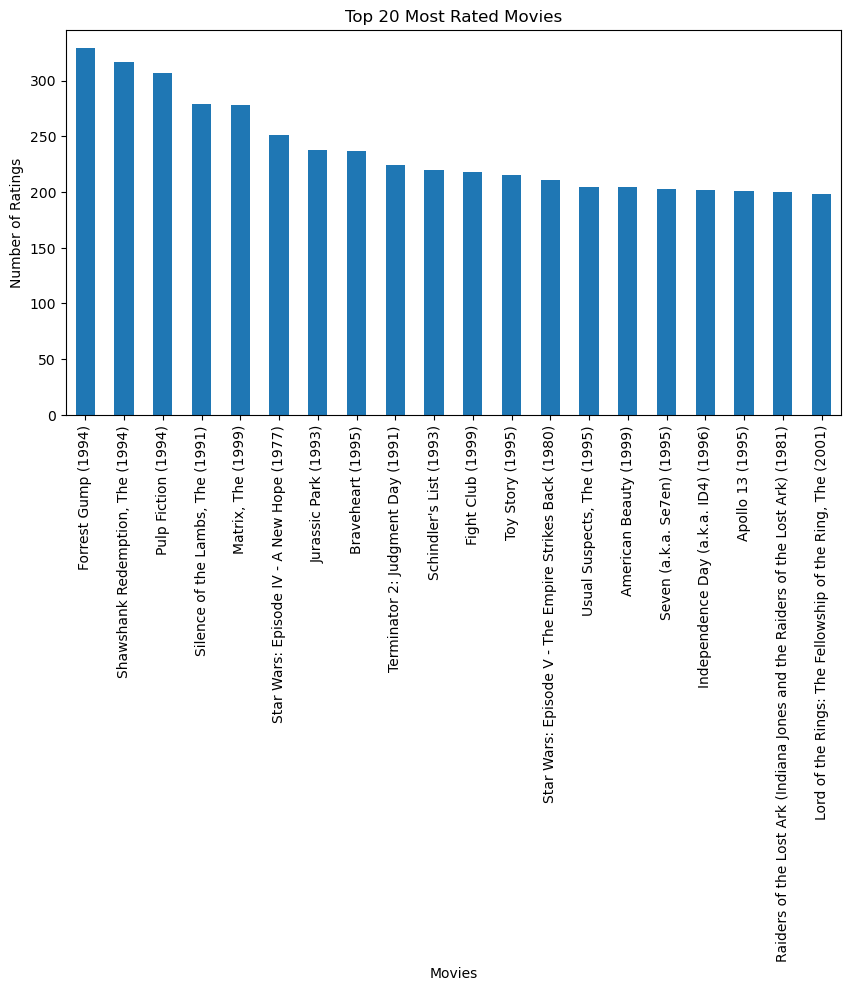

In [73]:
movie_counts = data.groupby('title')['rating'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
movie_counts.head(20).plot(kind='bar')
plt.title("Top 20 Most Rated Movies")
plt.xlabel("Movies")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=90)
plt.show()

In [74]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))

data_surprise = Dataset.load_from_df(
    data[['userId', 'movieId', 'rating']],
    reader
)

print("Converted to Surprise format")

Converted to Surprise format


In [75]:
from surprise import SVD
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data_surprise, test_size=0.2)

model = SVD()
model.fit(trainset)

print("SVD Model trained successfully")

SVD Model trained successfully


In [76]:
from surprise import accuracy

predictions = model.test(testset)

rmse = accuracy.rmse(predictions)
print("Final RMSE:", rmse)

RMSE: 0.8668
Final RMSE: 0.8668058862253369


In [77]:
from collections import defaultdict

def precision_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)
    
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions = {}
    
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        top_k = user_ratings[:k]
        
        relevant = sum((true_r >= threshold) for (_, true_r) in top_k)
        recommended = len(top_k)
        
        precisions[uid] = relevant / recommended if recommended != 0 else 0
    
    return sum(precisions.values()) / len(precisions)

precision = precision_at_k(predictions)
print("Precision@5:", precision)

Precision@5: 0.7678434592227719


In [78]:
from collections import defaultdict

def precision_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []

    for uid, user_ratings in user_est_true.items():
        # sort by predicted rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        top_k = user_ratings[:k]

        relevant = sum((true_r >= threshold) for (_, true_r) in top_k)
        total = len(top_k)

        if total > 0:
            precisions.append(relevant / total)

    return np.mean(precisions)

In [79]:
precision = precision_at_k(predictions, k=10)
print("Precision@10:", precision)

Precision@10: 0.7325807334428024


In [80]:
def recommend_movies(user_id, n=5):
    movie_ids = data['movieId'].unique()
    
    predictions = []
    
    for movie_id in movie_ids:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    top_movies = predictions[:n]
    
    recommended_titles = []
    
    for movie_id, _ in top_movies:
        title = movies[movies['movieId'] == movie_id]['title'].values[0]
        recommended_titles.append(title)
    
    return recommended_titles

In [81]:
print("Recommendations for User 101:")
recommend_movies(101, 5)

Recommendations for User 101:


['In Bruges (2008)',
 'Fight Club (1999)',
 'Shawshank Redemption, The (1994)',
 'Lawrence of Arabia (1962)',
 'City of God (Cidade de Deus) (2002)']

In [82]:
def recommend_with_cold_start(user_id, n=5):
    
    # if user not in training data
    if user_id not in data['userId'].values:
        print("New user → showing popular movies")

        popular = data.groupby('title')['rating'].count().sort_values(ascending=False)

        return popular.head(n).index.tolist()

    else:
        return recommend_movies(user_id, n)

In [83]:
recommend_with_cold_start(9999)   

New user → showing popular movies


['Forrest Gump (1994)',
 'Shawshank Redemption, The (1994)',
 'Pulp Fiction (1994)',
 'Silence of the Lambs, The (1991)',
 'Matrix, The (1999)']

In [88]:
def recommend_similar_movies(movie_name, n=5):
    
    
    movie_id = movies[movies['title'].str.contains(movie_name, case=False)]['movieId'].values[0]
    

    users_who_liked = data[(data['movieId'] == movie_id) & (data['rating'] >= 4)]['userId'].unique()
    
   
    recommendations = {}
    
    for user in users_who_liked:
        for m_id in movies['movieId'].unique():
            
            if m_id != movie_id:
                pred = model.predict(user, m_id).est
                
                if m_id in recommendations:
                    recommendations[m_id] += pred
                else:
                    recommendations[m_id] = pred
    
   
    recommended_movies = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    
   
    top_movies = []
    
    for m_id, _ in recommended_movies[:n]:
        title = movies[movies['movieId'] == m_id]['title'].values[0]
        top_movies.append(title)
    
    return top_movies

In [91]:
print("For users who like Toy Story, we recommend:")
recommend_similar_movies("Toy Story", 5)

For users who like Toy Story, we recommend:


['Shawshank Redemption, The (1994)',
 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)',
 'Lawrence of Arabia (1962)',
 'High Noon (1952)',
 'Godfather, The (1972)']

In [90]:


def cold_start_recommendation(n=5):
    popular_movies = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
    
    top_movie_ids = popular_movies.head(n).index
    
    recommended = movies[movies['movieId'].isin(top_movie_ids)]['title']
    
    return recommended.tolist()


print("Cold Start Recommendations:")
cold_start_recommendation(5)

Cold Start Recommendations:


['Pulp Fiction (1994)',
 'Shawshank Redemption, The (1994)',
 'Forrest Gump (1994)',
 'Silence of the Lambs, The (1991)',
 'Matrix, The (1999)']

In [94]:
from surprise.model_selection import cross_validate

In [95]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [96]:
from surprise import KNNBasic
from surprise.model_selection import cross_validate

sim_options = {
    "name": "cosine",
    "user_based": True
}

user_model = KNNBasic(sim_options=sim_options)

results = cross_validate(user_model, data, measures=['RMSE'], cv=3, verbose=True)

print("User-Based RMSE:", results['test_rmse'].mean())

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE of algorithm KNNBasic on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9787  0.9786  0.9794  0.9789  0.0003  
Fit time          0.71    0.64    0.69    0.68    0.03    
Test time         3.98    4.42    3.97    4.13    0.21    
User-Based RMSE: 0.9789020671176428


In [98]:
from surprise import KNNBasic
from surprise.model_selection import cross_validate

sim_options = {
    "name": "cosine",
    "user_based": False  
}

item_model = KNNBasic(sim_options=sim_options)

item_results = cross_validate(item_model, data, measures=['RMSE'], cv=3, verbose=True)

print("Item-Based RMSE:", item_results['test_rmse'].mean())

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE of algorithm KNNBasic on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9833  0.9749  0.9717  0.9766  0.0049  
Fit time          13.92   15.48   14.36   14.59   0.66    
Test time         22.21   21.63   22.95   22.26   0.54    
Item-Based RMSE: 0.9766489201715131


In [99]:
from surprise import SVD
from surprise.model_selection import cross_validate

svd_model = SVD()

svd_results = cross_validate(svd_model, data, measures=['RMSE'], cv=3, verbose=True)

print("SVD RMSE:", svd_results['test_rmse'].mean())

Evaluating RMSE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.8758  0.8849  0.8782  0.8796  0.0039  
Fit time          1.73    2.31    2.41    2.15    0.30    
Test time         0.38    0.86    0.54    0.59    0.20    
SVD RMSE: 0.8796155524162937
